In [3]:
import pygmt
import geopandas as gpd
import pandas as pd


In [4]:
import geopandas as gpd
import os
import glob
folder = "gpxs_subsampled/"

gpxs = sorted(glob.glob('./gpxs_subsampled/*.gpx'))
gpxs

['./gpxs_subsampled/001.gpx',
 './gpxs_subsampled/002.gpx',
 './gpxs_subsampled/003.gpx',
 './gpxs_subsampled/004.gpx',
 './gpxs_subsampled/005.gpx',
 './gpxs_subsampled/006.gpx',
 './gpxs_subsampled/007.gpx',
 './gpxs_subsampled/008.gpx',
 './gpxs_subsampled/009.gpx',
 './gpxs_subsampled/010.gpx',
 './gpxs_subsampled/011.gpx',
 './gpxs_subsampled/012.gpx',
 './gpxs_subsampled/013.gpx',
 './gpxs_subsampled/014.gpx',
 './gpxs_subsampled/015.gpx',
 './gpxs_subsampled/016.gpx',
 './gpxs_subsampled/017.gpx',
 './gpxs_subsampled/018.gpx',
 './gpxs_subsampled/019.gpx',
 './gpxs_subsampled/020.gpx',
 './gpxs_subsampled/021.gpx',
 './gpxs_subsampled/022.gpx',
 './gpxs_subsampled/023.gpx',
 './gpxs_subsampled/024.gpx',
 './gpxs_subsampled/025.gpx',
 './gpxs_subsampled/026.gpx',
 './gpxs_subsampled/027.gpx',
 './gpxs_subsampled/028.gpx',
 './gpxs_subsampled/029.gpx',
 './gpxs_subsampled/030.gpx',
 './gpxs_subsampled/031.gpx',
 './gpxs_subsampled/032.gpx',
 './gpxs_subsampled/033.gpx',
 './gpxs_s

In [5]:
# Create empty GeoDataFrame
track = gpd.GeoDataFrame(columns=['name', 'geometry'], 
     geometry='geometry')

for g in gpxs:
    gdf = gpd.read_file(g, layer='tracks')
    #gdf.plot()
    #track = track.append(gdf[['name', 'geometry']])

In [17]:


track.sort_values(by="name", inplace=True)
track.reset_index(inplace=True, drop=True)

<Axes: >

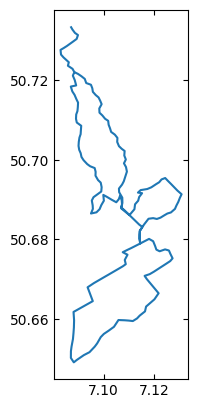

In [18]:
gdf.plot()

In [ ]:
track= gdf

lat_min, long_min, lat_max, long_max = track.total_bounds

# Add some margin
lat_min -= 0.05
lat_max += 0.05
long_max += 0.03
long_min -= 0.03

region = [lat_min, lat_max, long_min, long_max]

grid = pygmt.datasets.load_earth_relief(resolution="01s", region=region)

fig = pygmt.Figure()
fig.grdimage(grid=grid, projection="M15c", cmap="dem2", shading=True)
#fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])

# Plot borders
fig.coast(borders=["1/0.5p,red,..-"], resolution="f")

# Plot track
fig.plot(data=track, pen="1.5p,white")
fig.plot(data=track, pen="0.8p,blue")
fig.show()

grdblend [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]
grdblend [NOTICE]: Earth Relief at 3x3 arc seconds tiles provided by SRTMGL3 (land only) [NASA/USGS].
grdblend [NOTICE]:   -> Download 1x1 degree grid tile (earth_relief_03s_g): N50E006


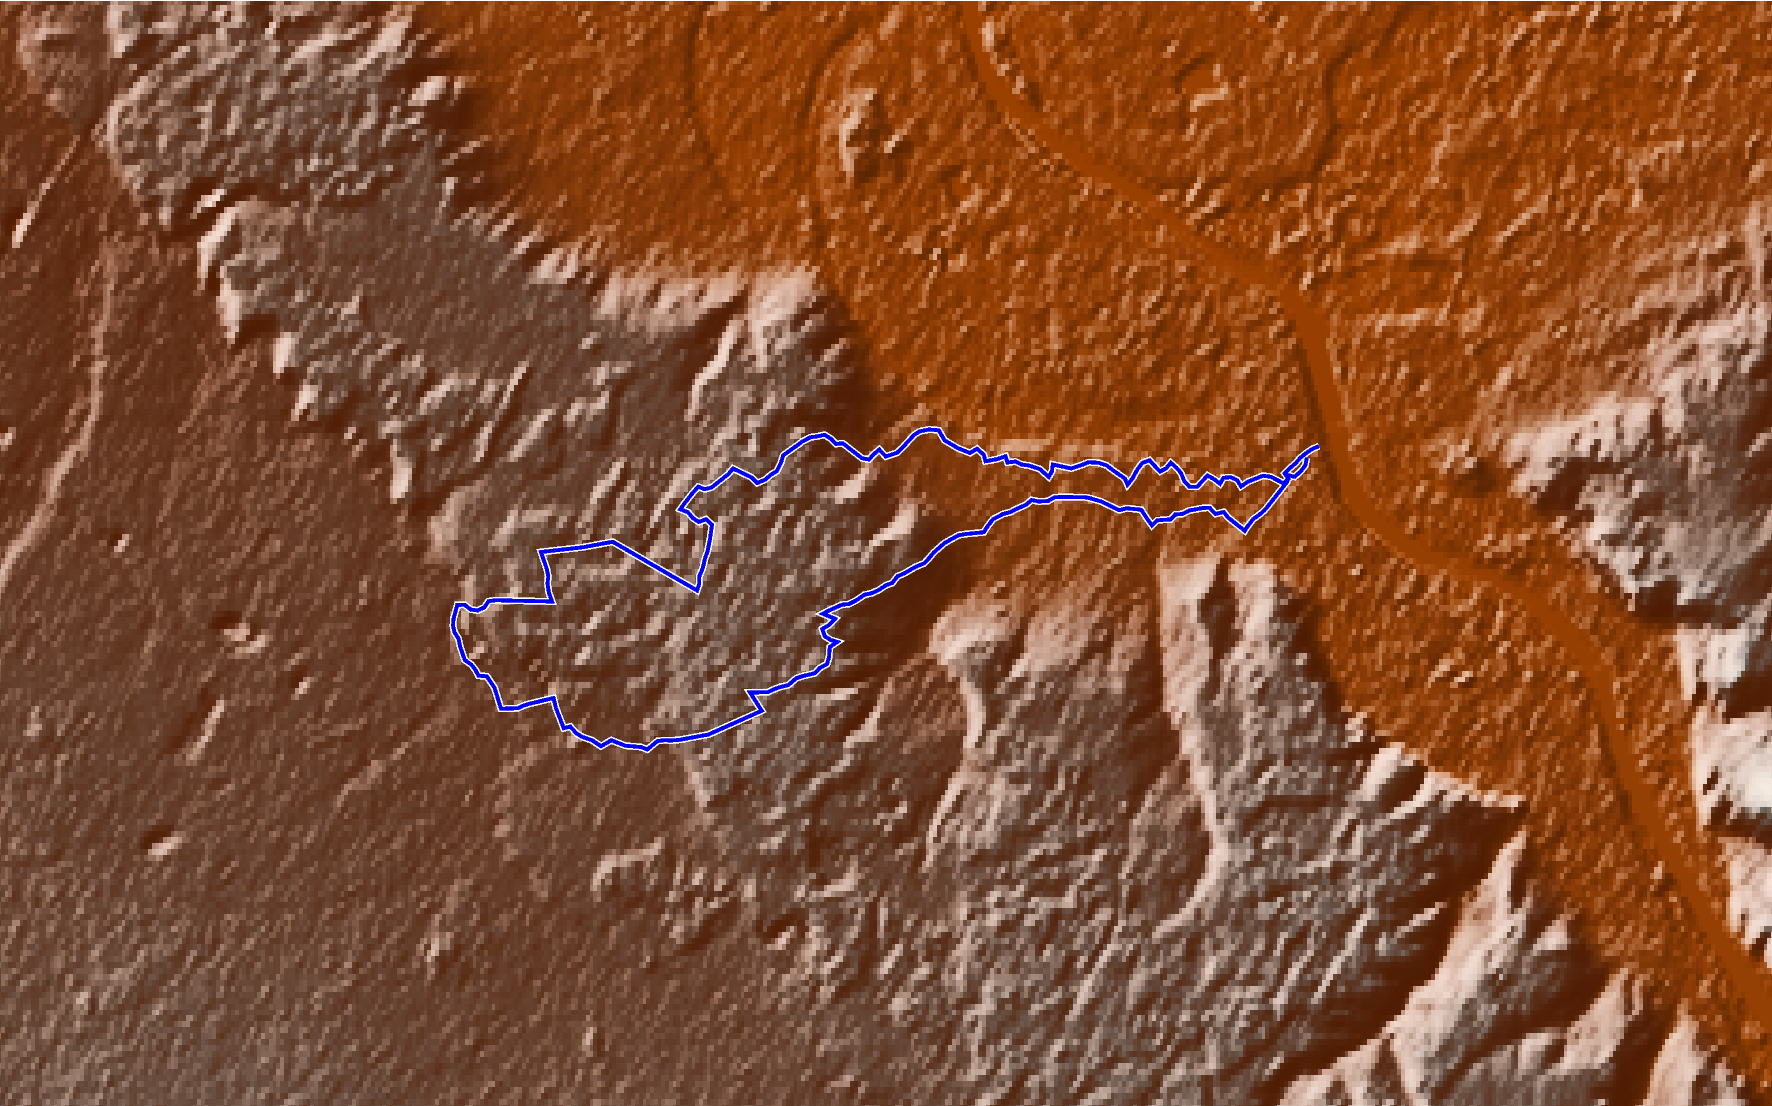

In [7]:
track= gdf

lat_min, long_min, lat_max, long_max = track.total_bounds

# Add some margin
lat_min -= 0.1
lat_max += 0.1
long_max += 0.06
long_min -= 0.05

region = [lat_min, lat_max, long_min, long_max]

grid = pygmt.datasets.load_earth_relief(resolution="03s", region=region)

fig = pygmt.Figure()
fig.grdimage(grid=grid, projection="M15c", cmap="dem2", shading=True)
#fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])

# Plot borders
fig.coast(borders=["1/0.5p,red,..-"], resolution="f")

# Plot track
fig.plot(data=track, pen="1.5p,white")
fig.plot(data=track, pen="0.8p,blue")
fig.show()